# K-Nearest Neighbor (KNN)

#### Simple Distance-Based Prediction
##### Dataset: from sklearn.datasets import load_wine
##### Task: Load a dataset like the Wine Quality dataset.
##### Action: Implement a KNN classifier with . Train the model, make predictions on a hold-out test set, and evaluate the accuracy

In [2]:
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy : {accuracy * 100:.2f}%\n")

Overall Accuracy : 80.56%



#### Hyperparameter Tuning (Finding the best 'k')
##### Dataset: from sklearn.datasets import load_wine
##### Task: The choice of drastically changes KNN's performance.
##### Action: Write a loop or use GridSearchCV to train a KNN model with values ranging from 1 to 30. Record the training accuracy and validation accuracy for each . Plot these accuracies on a line graph to visually identify the "sweet spot" where the model neither overfits nor underfits.

Best k         : 7
Best val acc   : 100.00%

k       Train Acc    Val Acc
----------------------------
1         100.00%     97.22%
2          97.18%     94.44%
3          97.18%     97.22%
4          95.77%     94.44%
5          97.89%     97.22%
6          96.48%     97.22%
7          96.48%    100.00% ◀ best
8          96.48%    100.00%
9          96.48%    100.00%
10         97.18%    100.00%
11         96.48%    100.00%
12         96.48%    100.00%
13         96.48%    100.00%
14         97.18%     97.22%
15         97.89%    100.00%
16         96.48%    100.00%
17         97.18%    100.00%
18         96.48%     97.22%
19         97.18%    100.00%
20         97.18%    100.00%
21         97.18%    100.00%
22         97.89%    100.00%
23         97.89%    100.00%
24         97.89%    100.00%
25         97.89%    100.00%
26         97.89%    100.00%
27         97.18%    100.00%
28         97.18%     97.22%
29         97.18%     97.22%
30         97.18%     97.22%


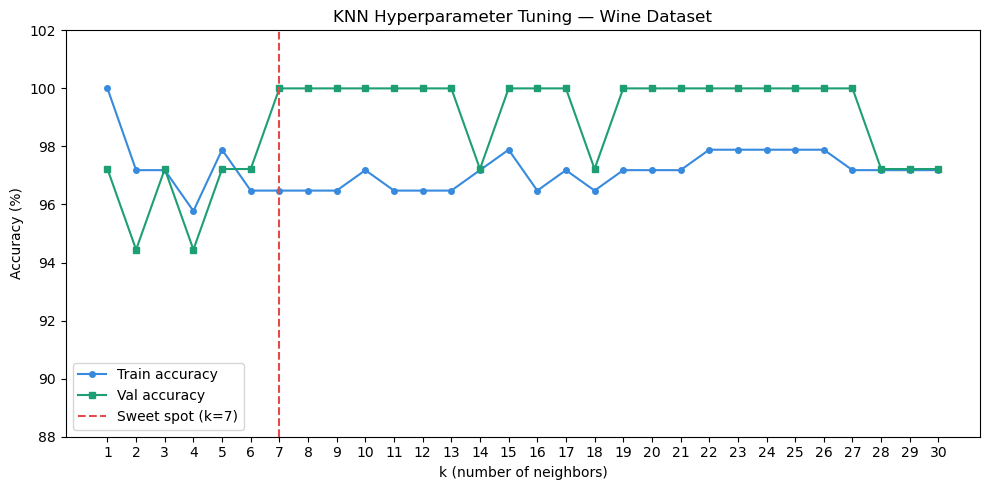

In [3]:
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
train_accs, test_accs = [], []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_accs.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accs.append(accuracy_score(y_test,  knn.predict(X_test_scaled)))
    best_k   = test_accs.index(max(test_accs)) + 1
best_acc = max(test_accs)
print(f"Best k         : {best_k}")
print(f"Best val acc   : {best_acc * 100:.2f}%\n")
print(f"{'k':<6} {'Train Acc':>10} {'Val Acc':>10}")
print("-" * 28)
for k, (tr, te) in enumerate(zip(train_accs, test_accs), 1):
    marker = " ◀ best" if k == best_k else ""print(f"{k:<6} {tr*100:>9.2f}% {te*100:>9.2f}%{marker}")k_range = range(1, 31)
plt.figure(figsize=(10, 5))
plt.plot(k_range, [a * 100 for a in train_accs], marker='o', markersize=4,label='Train accuracy', color='#378ADD')
plt.plot(k_range, [a * 100 for a in test_accs],  marker='s', markersize=4,label='Val accuracy',   color='#1D9E75')
plt.axvline(x=best_k, color='#E24B4A', linestyle='--', linewidth=1.5,label=f'Sweet spot (k={best_k})')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy (%)')
plt.title('KNN Hyperparameter Tuning — Wine Dataset')
plt.xticks(range(1, 31))
plt.ylim(88, 102)
plt.legend()
plt.tight_layout()
plt.savefig('knn_tuning.png', dpi=150)
plt.show()